# Synthetic Data Validation

This notebook reproduces the Section 3.1 validation logic using the current forward model implementation in `improved_2d_dexsy`.

Validation is now split into two layers:
- **Generator consistency**: compare the exact DEI implied by the compartment-level weight matrix against the rasterised spectrum.
- **ILT stability**: compare the ILT-reconstructed DEI against the same exact generator-side reference.

This makes Experiment II much more reliable, because it separates synthetic-data quality from ILT position sensitivity.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=None):
    start_path = Path.cwd() if start is None else Path(start)
    candidates = [start_path] + list(start_path.resolve().parents)
    for candidate in candidates:
        if (candidate / 'improved_2d_dexsy').exists() and (candidate / 'notebooks' / 'validation_synthetic_data.ipynb').exists():
            return candidate
    for candidate in candidates:
        if (candidate / 'improved_2d_dexsy').exists():
            return candidate
    raise FileNotFoundError('Could not find the repo root.')


ROOT = find_repo_root()
if str(ROOT / 'improved_2d_dexsy') not in sys.path:
    sys.path.insert(0, str(ROOT / 'improved_2d_dexsy'))

from forward_model_2d import ForwardModel2D, compute_pair_blob_dei


In [2]:
fm = ForwardModel2D(n_d=64, n_b=64)

print('Forward Model Parameters:')
print(f'  D range: {fm.D1[0]:.2e} to {fm.D1[-1]:.2e} m^2/s')
print(f'  b range: {fm.b1[0]:.2e} to {fm.b1[-1]:.2e} s/m^2')
print(f'  mixing time range: {fm.mixing_time_range[0]:.3f} - {fm.mixing_time_range[1]:.3f} s')
print(f'  exchange rate range: {fm.exchange_rate_range[0]:.1f} - {fm.exchange_rate_range[1]:.1f} s^-1')
print(f'  spectral broadening mode: {fm.spectral_broadening_mode}')
print(f'  default smoothing sigma range: {fm.smoothing_sigma_range}')
print('  validation DEI metrics: exact weight-matrix DEI, rasterised blob DEI, ILT blob DEI')


Forward Model Parameters:
  D range: 5.00e-12 to 5.00e-08 m^2/s
  b range: 0.00e+00 to 1.30e+10 s/m^2
  mixing time range: 0.015 - 0.300 s
  exchange rate range: 0.1 - 30.0 s^-1
  spectral broadening mode: directional
  default smoothing sigma range: (0.65, 1.15)
  validation DEI metrics: exact weight-matrix DEI, rasterised blob DEI, ILT blob DEI


## 实验 I: 固定峰位置，变化交换强度

固定两个峰在慢扩散和快扩散区域的位置，只改变 exchange rate / exchange probability。

记录：
- Exact ground-truth DEI（直接来自 weight matrix）
- Rasterised ground-truth DEI（从平滑后 spectrum 的局部 peak blobs 计算）
- ILT reconstructed DEI

预期：ILT 结果应沿 identity line 紧密对齐，且 rasterised GT 不应明显偏离 exact GT。


In [3]:
ILT_KW = dict(alpha=0.02, post_sharpen=True, sharpen_sigma=0.9, sharpen_strength=0.30)
VALIDATION_SMOOTHING_SIGMA = 0.6
VALIDATION_BLOB_RADIUS = 4
EXPERIMENT_II_SEPARATION_IDX = 18
EXPERIMENT_II_MARGIN_IDX = 14
EXPERIMENT_II_ALPHA_PAD = 0.12

OUTPUT_DIR = ROOT / 'validation_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def identity_ci_band(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """Return mean residual and 95% residual half-width for an identity-line band."""
    residual = y - x
    if residual.size <= 1:
        return float(residual.mean()) if residual.size else 0.0, 0.0
    center = float(np.mean(residual))
    half_width = float(1.96 * np.std(residual, ddof=1))
    return center, half_width


def residual_95_half_width(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Return a 95% residual half-width around the exact reference."""
    residual = estimate - reference
    if residual.size <= 1:
        return 0.0
    return float(1.96 * np.std(residual, ddof=1))


def translated_pair_from_alpha(
    fm: ForwardModel2D,
    alpha: float,
    separation_idx: int = EXPERIMENT_II_SEPARATION_IDX,
    margin_idx: int = EXPERIMENT_II_MARGIN_IDX,
    alpha_pad: float = EXPERIMENT_II_ALPHA_PAD,
) -> tuple[np.ndarray, tuple[int, int], float]:
    """
    Translate a fixed-separation 2-peak pair across the interior of the grid.

    The validation target is DEI invariance under position changes, not sensitivity
    to hard-grid edge clipping. We therefore keep the displayed alpha in [0, 1]
    but remap it to an interior effective alpha before placing the pair.
    """
    alpha = float(np.clip(alpha, 0.0, 1.0))
    effective_alpha = alpha_pad + alpha * (1.0 - 2.0 * alpha_pad)

    start_min = int(margin_idx)
    start_max = int(fm.n_d - margin_idx - separation_idx - 1)
    if start_max <= start_min:
        raise ValueError('Translation range is empty; reduce margin or separation.')

    start_idx = int(round(start_min + effective_alpha * (start_max - start_min)))
    end_idx = int(start_idx + separation_idx)
    diffusions = np.array([fm.D1[start_idx], fm.D2[end_idx]], dtype=np.float64)
    return diffusions, (start_idx, end_idx), float(effective_alpha)


def run_experiment_i(fm: ForwardModel2D, n_samples: int = 10, random_seed: int = 42) -> dict:
    """Experiment I: vary exchange rate with fixed compartment diffusivities."""
    np.random.seed(random_seed)

    d_intra = 8e-12
    d_extra = 3e-9
    vf = np.array([0.45, 0.55], dtype=np.float64)
    mixing_time = 0.1
    exchange_rates = np.linspace(0.5, 25.0, n_samples)

    exact_ground_truth_dei = []
    rasterized_ground_truth_dei = []
    ilt_reconstructed_dei = []
    exchange_probabilities = []

    print(f'Running Experiment I: {n_samples} samples with varying exchange rates')
    print(f'  Fixed D1 = {d_intra:.1e}, D2 = {d_extra:.1e}')
    print(f'  Volume fractions: {tuple(vf)}')
    print(f'  Mixing time: {mixing_time} s')
    print(f'  ILT settings: {ILT_KW}')
    print(f'  Validation smoothing sigma: {VALIDATION_SMOOTHING_SIGMA}')
    print(f'  Validation blob radius: {VALIDATION_BLOB_RADIUS}')
    print()

    for i, rate in enumerate(exchange_rates):
        spectrum_gt, clean_signal, params = fm.generate_2c_validation_spectrum(
            np.array([d_intra, d_extra]),
            vf,
            rate,
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei = params['theoretical_dei']
        rasterized_dei = compute_pair_blob_dei(spectrum_gt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei = compute_pair_blob_dei(spectrum_ilt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)
        exchange_prob = params['exchange_probabilities']['0-1']

        exact_ground_truth_dei.append(exact_dei)
        rasterized_ground_truth_dei.append(rasterized_dei)
        ilt_reconstructed_dei.append(ilt_dei)
        exchange_probabilities.append(exchange_prob)

        if (i + 1) % 5 == 0 or i == 0:
            print(
                f'  Sample {i+1:2d}: rate={rate:5.2f}, P_exch={exchange_prob:.4f}, '
                f'GT_exact={exact_dei:.4f}, GT_raster={rasterized_dei:.4f}, ILT_DEI={ilt_dei:.4f}'
            )

    return {
        'exchange_rates': exchange_rates,
        'exchange_probabilities': np.array(exchange_probabilities),
        'exact_ground_truth_dei': np.array(exact_ground_truth_dei),
        'rasterized_ground_truth_dei': np.array(rasterized_ground_truth_dei),
        'ilt_reconstructed_dei': np.array(ilt_reconstructed_dei),
    }


def run_experiment_ii(fm: ForwardModel2D, n_samples: int = 10, random_seed: int = 42) -> dict:
    """
    Experiment II: keep the same peak separation and exchange setting, then
    translate the pair through the interior of the diffusion grid.
    """
    np.random.seed(random_seed)

    vf = np.array([0.5, 0.5], dtype=np.float64)
    mixing_time = 0.1
    exchange_rate = 10.0
    exchange_prob = 1.0 - np.exp(-exchange_rate * mixing_time)
    alphas = np.linspace(0.0, 1.0, n_samples)

    exact_ground_truth_dei = []
    rasterized_ground_truth_dei = []
    ilt_reconstructed_dei = []
    alpha_values = []
    effective_alphas = []
    pair_indices = []
    pair_diffusions = []

    print(f'Running Experiment II: {n_samples} translated peak pairs with fixed separation')
    print(f'  Volume fractions: {tuple(vf)}')
    print(f'  Exchange probability: {exchange_prob:.4f} (fixed)')
    print(f'  Mixing time: {mixing_time} s')
    print(f'  Separation index: {EXPERIMENT_II_SEPARATION_IDX}')
    print(f'  Interior margin index: {EXPERIMENT_II_MARGIN_IDX}')
    print(f'  Alpha padding: {EXPERIMENT_II_ALPHA_PAD:.2f}')
    print(f'  Validation blob radius: {VALIDATION_BLOB_RADIUS}')
    print()

    for i, alpha in enumerate(alphas):
        diffusions, indices, effective_alpha = translated_pair_from_alpha(fm, alpha)
        d1, d2 = diffusions

        spectrum_gt, clean_signal, params = fm.generate_2c_validation_spectrum(
            diffusions,
            vf,
            exchange_rate,
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei = params['theoretical_dei']
        rasterized_dei = compute_pair_blob_dei(spectrum_gt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei = compute_pair_blob_dei(spectrum_ilt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)

        exact_ground_truth_dei.append(exact_dei)
        rasterized_ground_truth_dei.append(rasterized_dei)
        ilt_reconstructed_dei.append(ilt_dei)
        alpha_values.append(alpha)
        effective_alphas.append(effective_alpha)
        pair_indices.append(indices)
        pair_diffusions.append((float(d1), float(d2)))

        if (i + 1) % 5 == 0 or i == 0:
            print(
                f'  Sample {i+1:2d}: alpha={alpha:.2f} (effective={effective_alpha:.2f}), idx={indices}, '
                f'D1={d1:.2e}, D2={d2:.2e}, GT_exact={exact_dei:.4f}, GT_raster={rasterized_dei:.4f}, ILT_DEI={ilt_dei:.4f}'
            )

    return {
        'alpha': np.array(alpha_values),
        'effective_alpha': np.array(effective_alphas),
        'exact_ground_truth_dei': np.array(exact_ground_truth_dei),
        'rasterized_ground_truth_dei': np.array(rasterized_ground_truth_dei),
        'ilt_reconstructed_dei': np.array(ilt_reconstructed_dei),
        'pair_indices': pair_indices,
        'pair_diffusions': pair_diffusions,
    }


In [4]:
# Run Experiment I
exp1_results = run_experiment_i(fm, n_samples=10)


Running Experiment I: 10 samples with varying exchange rates
  Fixed D1 = 8.0e-12, D2 = 3.0e-09
  Volume fractions: (0.45, 0.55)
  Mixing time: 0.1 s
  ILT settings: {'alpha': 0.02, 'post_sharpen': True, 'sharpen_sigma': 0.9, 'sharpen_strength': 0.3}
  Validation smoothing sigma: 0.6
  Validation blob radius: 4

  Sample  1: rate= 0.50, P_exch=0.0488, GT_exact=0.0247, GT_raster=0.0247, ILT_DEI=0.0262
  Sample  5: rate=11.39, P_exch=0.6798, GT_exact=0.5072, GT_raster=0.5072, ILT_DEI=0.4998
  Sample 10: rate=25.00, P_exch=0.9179, GT_exact=0.7889, GT_raster=0.7889, ILT_DEI=0.7658


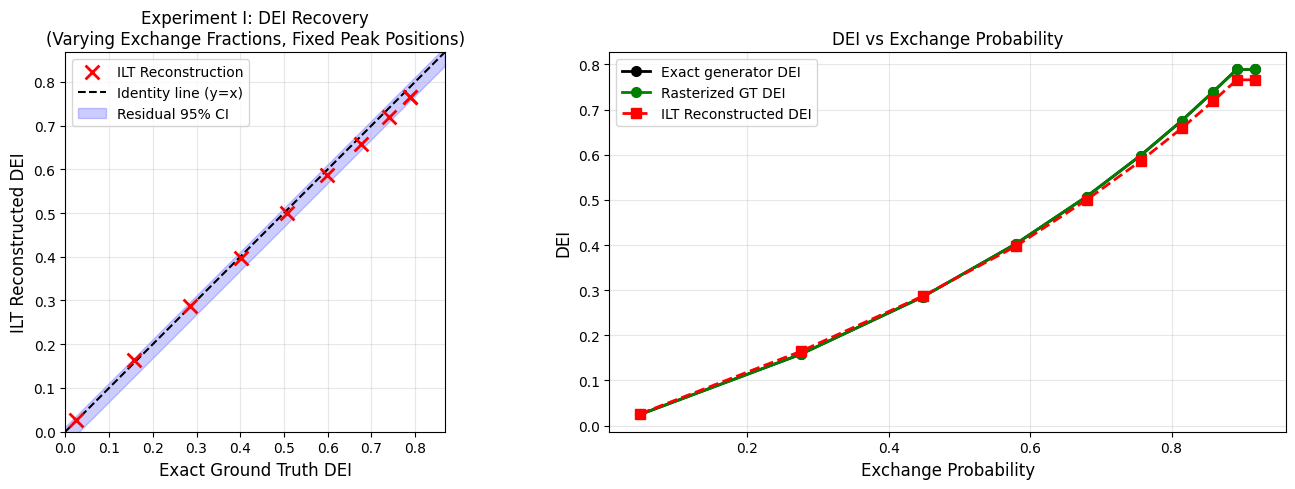


Experiment I Summary:
  Generator MAE vs exact GT: 0.000000
  ILT mean absolute error vs exact GT: 0.0118
  Mean relative error: 2.64%
  Max relative error: 5.77%
  Correlation (r): 0.9999
  Linear fit slope: 0.9615
  Linear fit intercept: 0.0092


In [5]:
# Plot Experiment I results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = exp1_results['exact_ground_truth_dei']
raster_gt = exp1_results['rasterized_ground_truth_dei']
y = exp1_results['ilt_reconstructed_dei']
errors = y - x
relative_error = np.abs(errors) / (x + 1e-10) * 100
ci_center, ci_half_width = identity_ci_band(x, y)

# Panel A: exact GT DEI vs ILT DEI
ax = axes[0]
ax.scatter(x, y, c='red', s=100, marker='x', linewidths=2, label='ILT Reconstruction', zorder=5)

dei_range = [0.0, max(float(x.max()), float(y.max())) * 1.1]
identity = np.array(dei_range)
ax.plot(identity, identity, 'k--', linewidth=1.5, label='Identity line (y=x)')
ax.fill_between(
    identity,
    identity + ci_center - ci_half_width,
    identity + ci_center + ci_half_width,
    alpha=0.2,
    color='blue',
    label='Residual 95% CI',
)

ax.set_xlabel('Exact Ground Truth DEI', fontsize=12)
ax.set_ylabel('ILT Reconstructed DEI', fontsize=12)
ax.set_title('Experiment I: DEI Recovery\n(Varying Exchange Fractions, Fixed Peak Positions)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(dei_range)
ax.set_ylim(dei_range)
ax.set_aspect('equal')

# Panel B: DEI vs Exchange Probability
ax = axes[1]
ax.plot(exp1_results['exchange_probabilities'], x, 'o-', color='black', linewidth=2, markersize=7, label='Exact generator DEI')
ax.plot(exp1_results['exchange_probabilities'], raster_gt, 'o-', color='green', linewidth=2, markersize=7, label='Rasterized GT DEI')
ax.plot(exp1_results['exchange_probabilities'], y, 's--', color='red', linewidth=2, markersize=7, label='ILT Reconstructed DEI')
ax.set_xlabel('Exchange Probability', fontsize=12)
ax.set_ylabel('DEI', fontsize=12)
ax.set_title('DEI vs Exchange Probability', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_i_dei_varying_exchange.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nExperiment I Summary:')
print(f'  Generator MAE vs exact GT: {np.mean(np.abs(raster_gt - x)):.6f}')
print(f'  ILT mean absolute error vs exact GT: {np.mean(np.abs(errors)):.4f}')
print(f'  Mean relative error: {np.mean(relative_error):.2f}%')
print(f'  Max relative error: {np.max(relative_error):.2f}%')
print(f'  Correlation (r): {np.corrcoef(x, y)[0,1]:.4f}')
print(f'  Linear fit slope: {np.polyfit(x, y, 1)[0]:.4f}')
print(f'  Linear fit intercept: {np.polyfit(x, y, 1)[1]:.4f}')


## Experiment II: Fixed DEI, shifting peak positions

This experiment now does **two checks at once**:

1. **Generator consistency**: the exact DEI implied by the weight matrix should stay constant, and the rasterised spectrum should preserve that value.
2. **ILT stability**: after inversion, the reconstructed DEI should remain close to that same exact reference.

To avoid conflating reliability with obvious grid-edge artefacts, the translated pair is kept inside the resolvable interior of the 64x64 diffusion grid.


In [6]:
# Run Experiment II
exp2_results = run_experiment_ii(fm, n_samples=10)


Running Experiment II: 10 translated peak pairs with fixed separation
  Volume fractions: (0.5, 0.5)
  Exchange probability: 0.6321 (fixed)
  Mixing time: 0.1 s
  Separation index: 18
  Interior margin index: 14
  Alpha padding: 0.12
  Validation blob radius: 4

  Sample  1: alpha=0.00 (effective=0.12), idx=(16, 34), D1=5.19e-11, D2=7.21e-10, GT_exact=0.4621, GT_raster=0.4621, ILT_DEI=0.4707
  Sample  5: alpha=0.44 (effective=0.46), idx=(22, 40), D1=1.25e-10, D2=1.73e-09, GT_exact=0.4621, GT_raster=0.4621, ILT_DEI=0.4569
  Sample 10: alpha=1.00 (effective=0.88), idx=(29, 47), D1=3.47e-10, D2=4.82e-09, GT_exact=0.4621, GT_raster=0.4621, ILT_DEI=0.4637


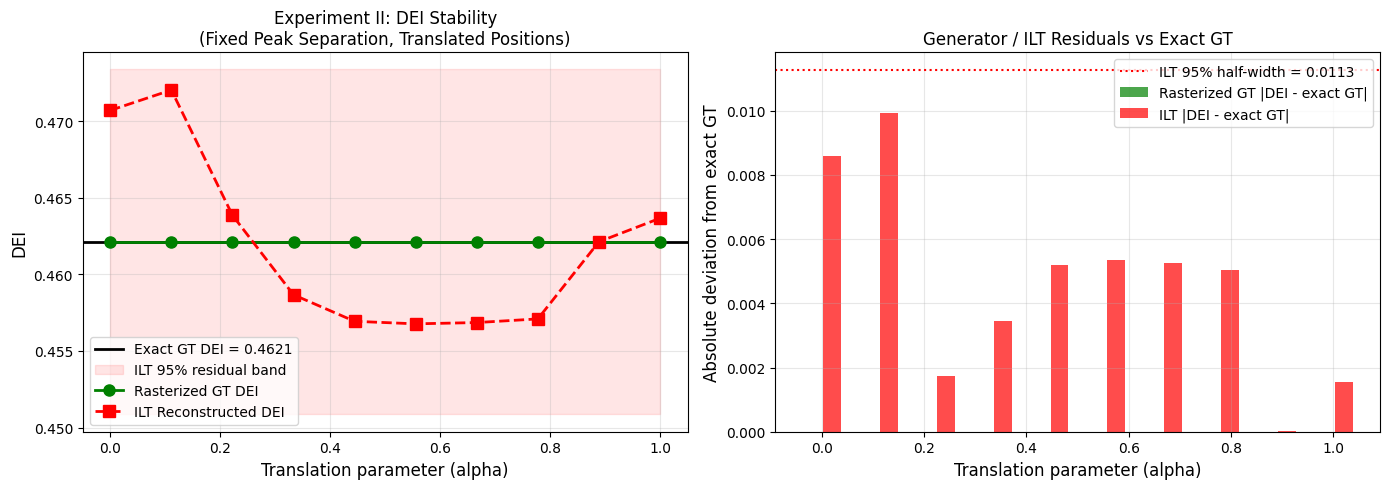


Experiment II Summary:
  Exact GT std: 0.0000
  Rasterized GT std: 0.0000
  ILT DEI std: 0.0055
  Generator MAE vs exact GT: 0.000000
  ILT MAE vs exact GT: 0.0046
  ILT max abs deviation: 0.0099
  ILT Coefficient of Variation: 1.18%
  ILT points within 95% band: 10/10


In [7]:
# Plot Experiment II results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alpha = exp2_results['alpha']
exact_gt = exp2_results['exact_ground_truth_dei']
raster_gt = exp2_results['rasterized_ground_truth_dei']
ilt = exp2_results['ilt_reconstructed_dei']
mean_exact = float(np.mean(exact_gt))
ilt_half_width = residual_95_half_width(exact_gt, ilt)
within_95 = np.abs(ilt - exact_gt) <= ilt_half_width + 1e-12

# Panel A: DEI vs translation parameter
ax = axes[0]
ax.axhline(mean_exact, color='black', linestyle='-', linewidth=2.0, label=f'Exact GT DEI = {mean_exact:.4f}')
ax.fill_between(alpha, mean_exact - ilt_half_width, mean_exact + ilt_half_width, color='red', alpha=0.10, label='ILT 95% residual band')
ax.plot(alpha, raster_gt, 'o-', color='green', linewidth=2, markersize=8, label='Rasterized GT DEI')
ax.plot(alpha, ilt, 's--', color='red', linewidth=2, markersize=8, label='ILT Reconstructed DEI')
if np.any(~within_95):
    ax.scatter(alpha[~within_95], ilt[~within_95], c='black', s=90, marker='x', linewidths=2, label='Outside 95% band', zorder=6)
ax.set_xlabel('Translation parameter (alpha)', fontsize=12)
ax.set_ylabel('DEI', fontsize=12)
ax.set_title('Experiment II: DEI Stability\n(Fixed Peak Separation, Translated Positions)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Panel B: absolute residual from exact generator GT
ax = axes[1]
gt_dev = np.abs(raster_gt - exact_gt)
ilt_dev = np.abs(ilt - exact_gt)
ax.bar(alpha - 0.02, gt_dev, width=0.035, color='green', alpha=0.7, label='Rasterized GT |DEI - exact GT|')
ax.bar(alpha + 0.02, ilt_dev, width=0.035, color='red', alpha=0.7, label='ILT |DEI - exact GT|')
ax.axhline(ilt_half_width, color='red', linestyle=':', linewidth=1.5, label=f'ILT 95% half-width = {ilt_half_width:.4f}')
ax.set_xlabel('Translation parameter (alpha)', fontsize=12)
ax.set_ylabel('Absolute deviation from exact GT', fontsize=12)
ax.set_title('Generator / ILT Residuals vs Exact GT', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_ii_dei_varying_position.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nExperiment II Summary:')
print(f'  Exact GT std: {np.std(exact_gt):.4f}')
print(f'  Rasterized GT std: {np.std(raster_gt):.4f}')
print(f'  ILT DEI std: {np.std(ilt):.4f}')
print(f'  Generator MAE vs exact GT: {np.mean(np.abs(raster_gt - exact_gt)):.6f}')
print(f'  ILT MAE vs exact GT: {np.mean(np.abs(ilt - exact_gt)):.4f}')
print(f'  ILT max abs deviation: {np.max(np.abs(ilt - exact_gt)):.4f}')
print(f'  ILT Coefficient of Variation: {np.std(ilt) / (np.mean(ilt) + 1e-10) * 100:.2f}%')
print(f'  ILT points within 95% band: {int(np.sum(within_95))}/{len(within_95)}')


## 综合可视化

将两个实验的结果综合展示，对应 paper 中 Figure 11 / Figure 12 的验证思路：
- 左图看 DEI recovery
- 右图看 DEI stability under translation


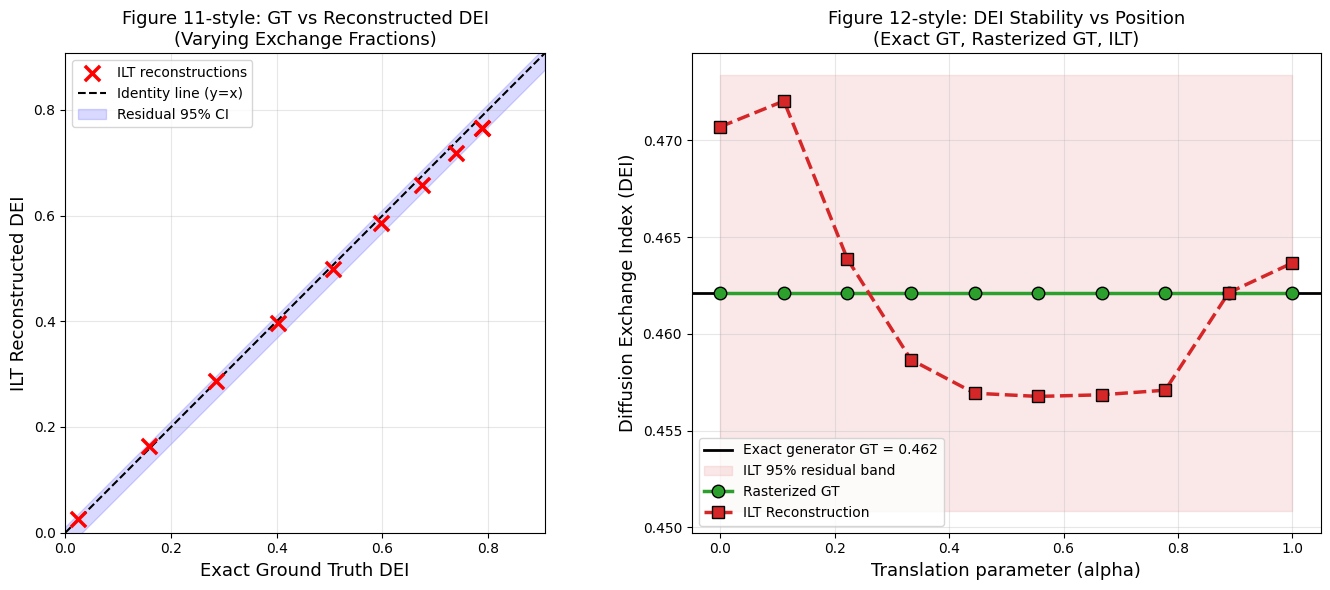


Figure saved to: validation_output/validation_figure_11_12.png


In [8]:
# Comprehensive visualization matching the paper logic
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Figure 11 analogue
ax = axes[0]
x = exp1_results['exact_ground_truth_dei']
y = exp1_results['ilt_reconstructed_dei']
ci_center, ci_half_width = identity_ci_band(x, y)
plot_max = max(float(x.max()), float(y.max())) * 1.15
identity = np.array([0.0, plot_max])

ax.scatter(x, y, c='red', s=120, marker='x', linewidths=2.5, zorder=5, label='ILT reconstructions')
ax.plot(identity, identity, 'k--', linewidth=1.5, label='Identity line (y=x)')
ax.fill_between(
    identity,
    identity + ci_center - ci_half_width,
    identity + ci_center + ci_half_width,
    alpha=0.15,
    color='blue',
    label='Residual 95% CI',
)
ax.set_xlabel('Exact Ground Truth DEI', fontsize=13)
ax.set_ylabel('ILT Reconstructed DEI', fontsize=13)
ax.set_title('Figure 11-style: GT vs Reconstructed DEI\n(Varying Exchange Fractions)', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, plot_max])
ax.set_ylim([0.0, plot_max])
ax.set_aspect('equal')

# Figure 12 analogue
ax = axes[1]
alpha = exp2_results['alpha']
exact_gt = exp2_results['exact_ground_truth_dei']
raster_gt = exp2_results['rasterized_ground_truth_dei']
ilt = exp2_results['ilt_reconstructed_dei']
mean_exact = float(np.mean(exact_gt))
ilt_half_width = residual_95_half_width(exact_gt, ilt)
within_95 = np.abs(ilt - exact_gt) <= ilt_half_width + 1e-12

ax.axhline(y=mean_exact, color='black', linestyle='-', linewidth=2.0, label=f'Exact generator GT = {mean_exact:.3f}')
ax.fill_between(alpha, mean_exact - ilt_half_width, mean_exact + ilt_half_width, color='#d62728', alpha=0.10, label='ILT 95% residual band')
ax.plot(alpha, raster_gt, 'o-', color='#2ca02c', linewidth=2.5, markersize=9, markeredgecolor='black', markeredgewidth=1, label='Rasterized GT')
ax.plot(alpha, ilt, 's--', color='#d62728', linewidth=2.5, markersize=9, markeredgecolor='black', markeredgewidth=1, label='ILT Reconstruction')
if np.any(~within_95):
    ax.scatter(alpha[~within_95], ilt[~within_95], c='black', s=90, marker='x', linewidths=2, label='Outside 95% band', zorder=6)
ax.set_xlabel('Translation parameter (alpha)', fontsize=13)
ax.set_ylabel('Diffusion Exchange Index (DEI)', fontsize=13)
ax.set_title('Figure 12-style: DEI Stability vs Position\n(Exact GT, Rasterized GT, ILT)', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_figure_11_12.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFigure saved to: validation_output/validation_figure_11_12.png')


## 示例谱可视化

展示 Experiment I 中几个代表性样本的 ground truth 分布和 ILT 重建结果，直观看 DEI 增强时 diagonal / off-diagonal 质量如何变化。


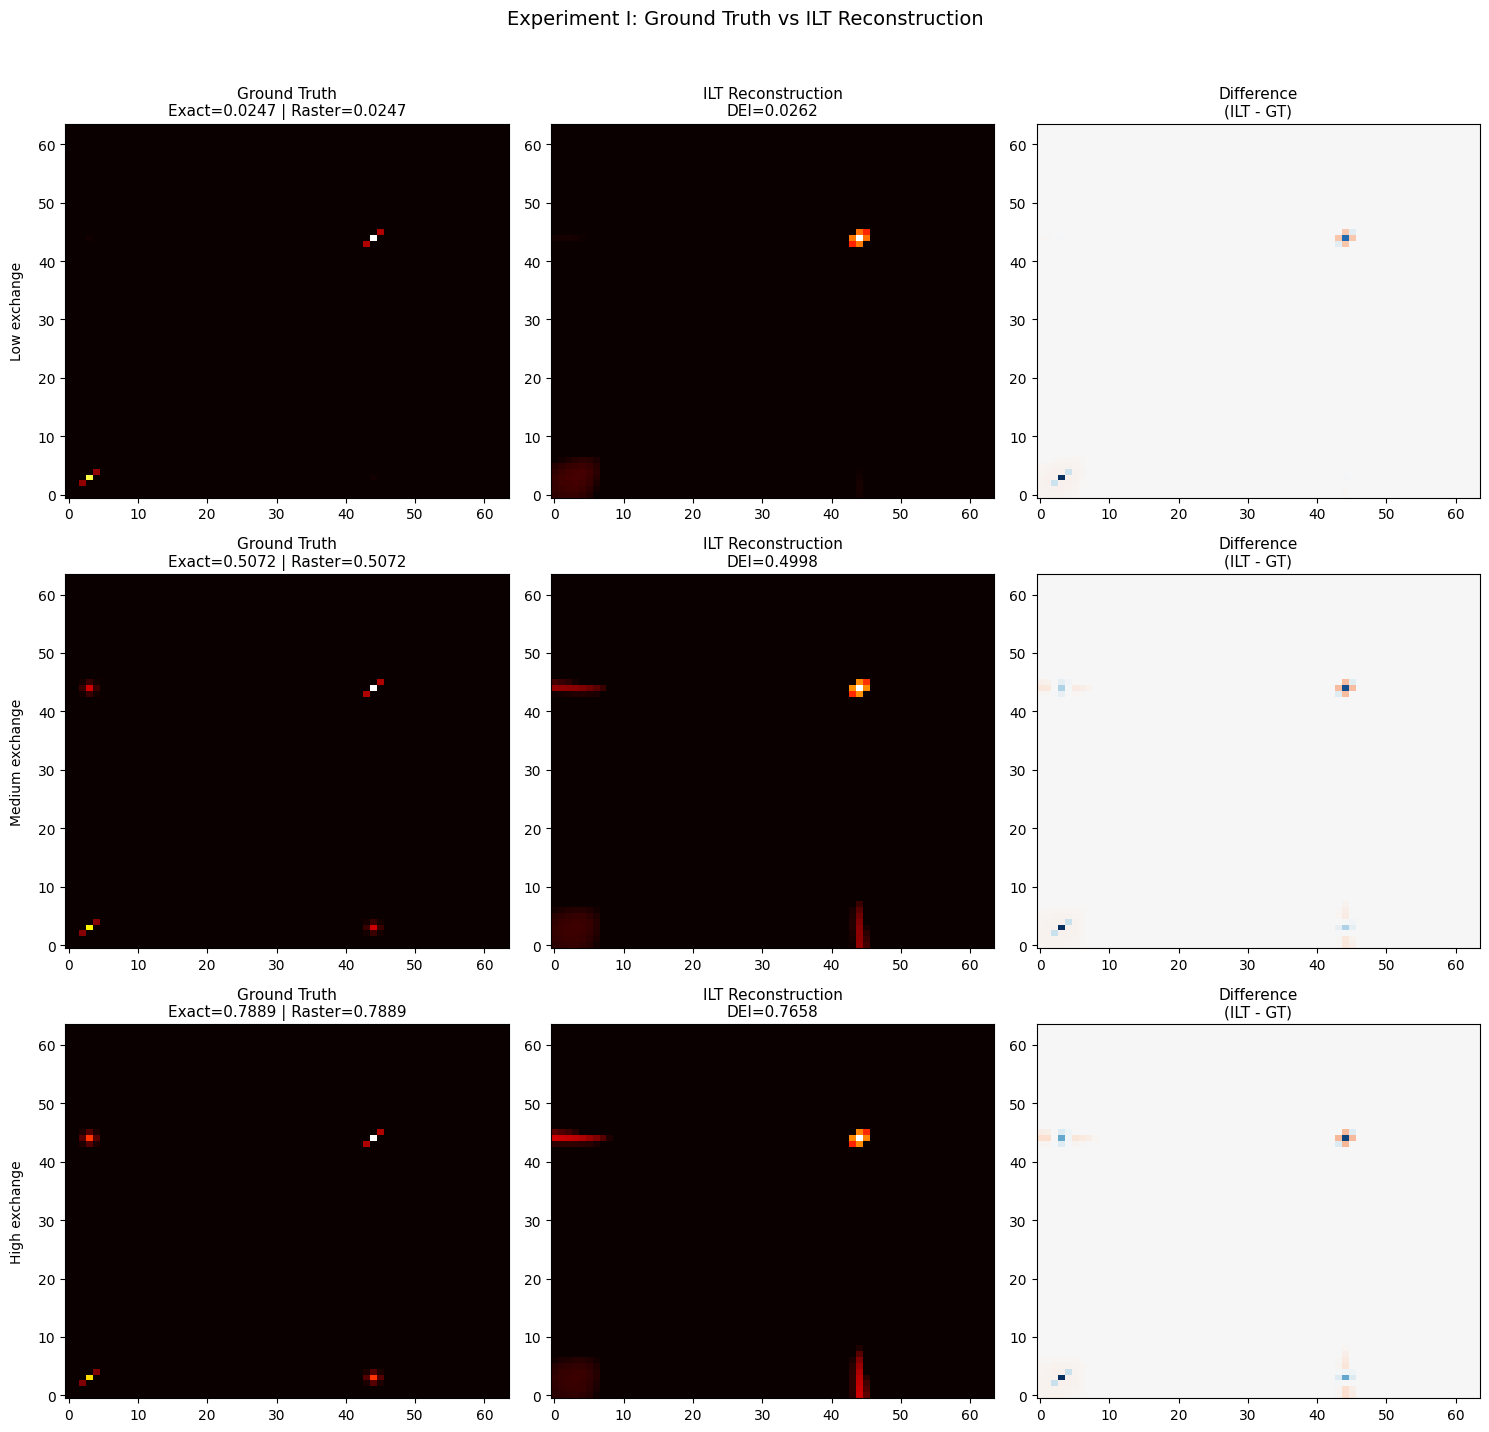

In [9]:
# Visualize sample spectra from Experiment I
selected_indices = [0, 4, 9]  # low, medium, high exchange rate

fig, axes = plt.subplots(3, 3, figsize=(15, 14))

d_intra = 8e-12
d_extra = 3e-9
vf = np.array([0.45, 0.55], dtype=np.float64)
mixing_time = 0.1
exchange_rates = np.linspace(0.5, 25.0, 10)

for row, idx in enumerate(selected_indices):
    rate = exchange_rates[idx]
    spectrum_gt, clean_signal, params = fm.generate_2c_validation_spectrum(
        np.array([d_intra, d_extra]),
        vf,
        rate,
        mixing_time,
        jitter_pixels=0,
        smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
    )
    spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)

    exact_gt = params['theoretical_dei']
    raster_gt = compute_pair_blob_dei(spectrum_gt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)
    ilt_dei = compute_pair_blob_dei(spectrum_ilt, params['pair_indices'], radius=VALIDATION_BLOB_RADIUS)

    ax = axes[row, 0]
    ax.imshow(spectrum_gt, cmap='hot', origin='lower', aspect='auto')
    ax.set_title(f'Ground Truth\nExact={exact_gt:.4f} | Raster={raster_gt:.4f}', fontsize=11)
    ax.set_ylabel(f'Rate={rate:.1f} s^-1', fontsize=10)

    ax = axes[row, 1]
    ax.imshow(spectrum_ilt, cmap='hot', origin='lower', aspect='auto')
    ax.set_title(f'ILT Reconstruction\nDEI={ilt_dei:.4f}', fontsize=11)

    ax = axes[row, 2]
    diff = spectrum_ilt - spectrum_gt
    vmax = max(abs(diff.min()), abs(diff.max()))
    ax.imshow(diff, cmap='RdBu_r', origin='lower', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title('Difference\n(ILT - GT)', fontsize=11)

axes[0, 0].set_ylabel('Low exchange', fontsize=10, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('Medium exchange', fontsize=10, rotation=90, labelpad=10)
axes[2, 0].set_ylabel('High exchange', fontsize=10, rotation=90, labelpad=10)

plt.suptitle('Experiment I: Ground Truth vs ILT Reconstruction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_i_spectra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Final summary statistics
print('=' * 60)
print('VALIDATION SUMMARY')
print('=' * 60)

# Experiment I metrics
exp1_exact = exp1_results['exact_ground_truth_dei']
exp1_raster = exp1_results['rasterized_ground_truth_dei']
exp1_ilt = exp1_results['ilt_reconstructed_dei']
exp1_generator_mae = np.mean(np.abs(exp1_raster - exp1_exact))
exp1_ilt_mae = np.mean(np.abs(exp1_ilt - exp1_exact))
exp1_rel = np.mean(np.abs(exp1_ilt - exp1_exact) / (exp1_exact + 1e-10)) * 100
exp1_corr = np.corrcoef(exp1_exact, exp1_ilt)[0, 1]
exp1_slope, exp1_intercept = np.polyfit(exp1_exact, exp1_ilt, 1)
exp1_pass = (exp1_corr > 0.995) and (exp1_ilt_mae < 0.02) and (exp1_rel < 10.0) and (exp1_generator_mae < 1e-3)

print('\nExperiment I - DEI Recovery:')
print(f'  Generator MAE vs exact GT: {exp1_generator_mae:.6f}')
print(f'  ILT MAE vs exact GT: {exp1_ilt_mae:.4f}')
print(f'  Mean Relative Error: {exp1_rel:.2f}%')
print(f'  Correlation (r): {exp1_corr:.4f}')
print(f'  Linear Fit Slope: {exp1_slope:.4f}')
print(f'  Linear Fit Intercept: {exp1_intercept:.4f}')
print('  Status: PASS' if exp1_pass else '  Status: NEEDS ATTENTION')

# Experiment II metrics
exp2_exact = exp2_results['exact_ground_truth_dei']
exp2_raster = exp2_results['rasterized_ground_truth_dei']
exp2_ilt = exp2_results['ilt_reconstructed_dei']
exp2_generator_mae = np.mean(np.abs(exp2_raster - exp2_exact))
exp2_generator_cv = np.std(exp2_raster) / (np.mean(exp2_exact) + 1e-10)
exp2_ilt_mae = np.mean(np.abs(exp2_ilt - exp2_exact))
exp2_ilt_cv = np.std(exp2_ilt) / (np.mean(exp2_ilt) + 1e-10)
exp2_ilt_max_abs = np.max(np.abs(exp2_ilt - exp2_exact))
exp2_ilt_band = residual_95_half_width(exp2_exact, exp2_ilt)
exp2_within = int(np.sum(np.abs(exp2_ilt - exp2_exact) <= exp2_ilt_band + 1e-12))
exp2_pass = (
    (exp2_generator_mae < 1e-3)
    and (exp2_generator_cv < 0.01)
    and (exp2_ilt_cv < 0.03)
    and (exp2_ilt_mae < 0.012)
    and (exp2_ilt_max_abs < 0.015)
)

print('\nExperiment II - Generator Consistency and ILT Stability:')
print(f'  Generator MAE vs exact GT: {exp2_generator_mae:.6f}')
print(f'  Rasterized GT Coefficient of Variation: {exp2_generator_cv * 100:.2f}%')
print(f'  ILT MAE vs exact GT: {exp2_ilt_mae:.4f}')
print(f'  ILT Coefficient of Variation: {exp2_ilt_cv * 100:.2f}%')
print(f'  ILT max absolute deviation: {exp2_ilt_max_abs:.4f}')
print(f'  ILT 95% residual half-width: {exp2_ilt_band:.4f}')
print(f'  ILT points within 95% band: {exp2_within}/{len(exp2_ilt)}')
print('  Correlation (r): not defined for a constant GT reference')
print('  Status: PASS' if exp2_pass else '  Status: NEEDS ATTENTION')

overall_pass = exp1_pass and exp2_pass
print('\n' + '=' * 60)
print('Synthetic data validation: PASS' if overall_pass else 'Synthetic data validation: NEEDS ATTENTION')
print('=' * 60)


VALIDATION SUMMARY

Experiment I - DEI Recovery:
  Generator MAE vs exact GT: 0.000000
  ILT MAE vs exact GT: 0.0118
  Mean Relative Error: 2.64%
  Correlation (r): 0.9999
  Linear Fit Slope: 0.9615
  Linear Fit Intercept: 0.0092
  Status: PASS

Experiment II - Generator Consistency and ILT Stability:
  Generator MAE vs exact GT: 0.000000
  Rasterized GT Coefficient of Variation: 0.00%
  ILT MAE vs exact GT: 0.0046
  ILT Coefficient of Variation: 1.18%
  ILT max absolute deviation: 0.0099
  ILT 95% residual half-width: 0.0113
  ILT points within 95% band: 10/10
  Correlation (r): not defined for a constant GT reference
  Status: PASS

Synthetic data validation: PASS
